## Importing Modules

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Importing Dataset

In [2]:
data= pd.read_csv("retail_sales_dataset.csv")

## Data Cleaning


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
# Changing Datatype Of Date Column Into Date
data["Date"] = pd.to_datetime(data["Date"])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [16]:

print(f"Null Values Are:\n{data.isna().sum()}")

Shape OF Dataset Is:
(1000, 9)

Null Values Are:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
print(f"Shape OF Dataset Is:{data.shape}")

Shape OF Dataset Is:
(1000, 9)


In [18]:
data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [19]:
data.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [20]:
data.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [22]:

num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

desc_stats = data[num_cols].describe().T
desc_stats['median'] = data[num_cols].median()
desc_stats['mode'] = data[num_cols].mode().iloc[0]

desc_stats[['mean', 'median', 'mode', 'std', 'min', 'max']]

,mean,median,mode,std,min,max
Age,41.392,42.0,43.0,13.681430,18.0,64.0
Quantity,2.514,3.0,4.0,1.132734,1.0,4.0
Price per Unit,179.890,50.0,50.0,189.681356,25.0,500.0
Total Amount,456.000,135.0,50.0,559.997632,25.0,2000.0


## Visualization

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9348\3454656843.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


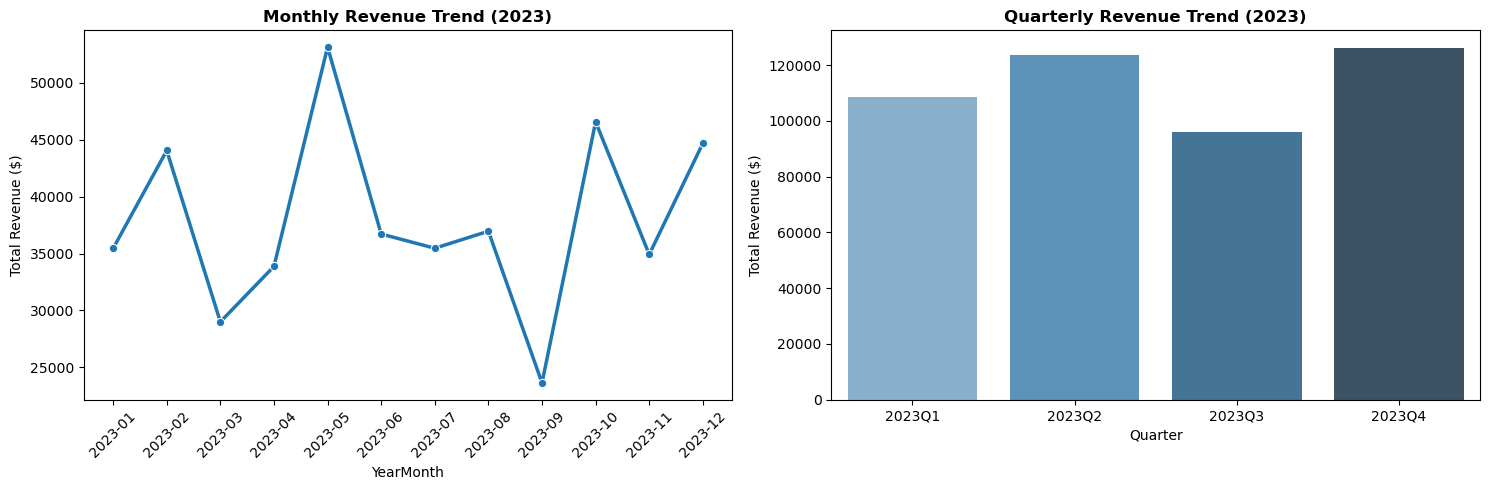

In [24]:
# Monthly and Quarterly Sales Aggregation
data_2023 = data[data['Date'].dt.year == 2023].copy()

data_2023['YearMonth'] = data_2023['Date'].dt.to_period('M').astype(str)
data_2023['Quarter'] = data_2023['Date'].dt.to_period('Q').astype(str)

monthly_sales = data_2023.groupby('YearMonth')['Total Amount'].sum().reset_index()
quarterly_sales = data_2023.groupby('Quarter')['Total Amount'].sum().reset_index()

# Plot Trends
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=monthly_sales,
    x='YearMonth',
    y='Total Amount',
    marker='o',
    ax=axes[0],
    color='#1f77b4',
    linewidth=2.5
)

axes[0].set_title('Monthly Revenue Trend (2023)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Total Revenue ($)')

sns.barplot(
    data=quarterly_sales,
    x='Quarter',
    y='Total Amount',
    ax=axes[1],
    palette='Blues_d'
)

axes[1].set_title('Quarterly Revenue Trend (2023)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9348\1170134322.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


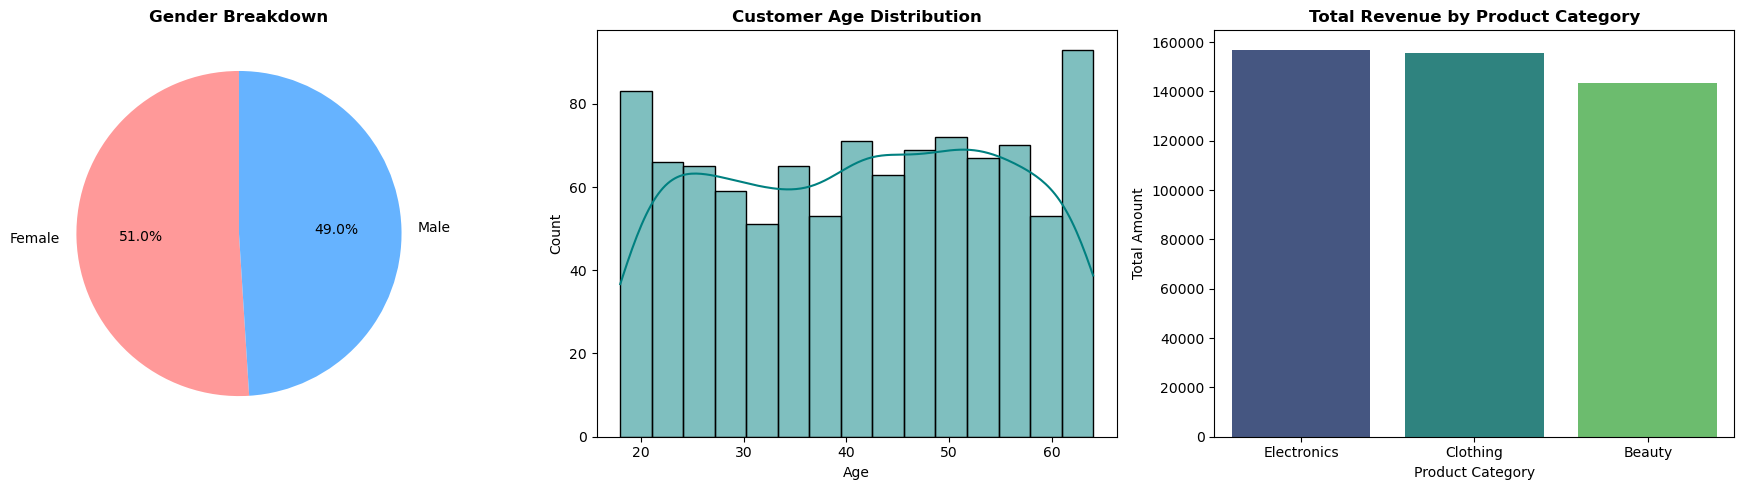

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender Distribution
gender_counts = data['Gender'].value_counts()
axes[0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff'],
    startangle=90
)
axes[0].set_title('Gender Breakdown', fontsize=12, fontweight='bold')

# Age Distribution
sns.histplot(
    data['Age'],
    kde=True,
    bins=15,
    ax=axes[1],
    color='teal'
)
axes[1].set_title('Customer Age Distribution', fontsize=12, fontweight='bold')

# Product Category Revenue
cat_revenue = (
    data.groupby('Product Category')['Total Amount']
    .sum()
    .reset_index()
    .sort_values(by='Total Amount', ascending=False)
)

sns.barplot(
    data=cat_revenue,
    x='Product Category',
    y='Total Amount',
    ax=axes[2],
    palette='viridis'
)
axes[2].set_title('Total Revenue by Product Category', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

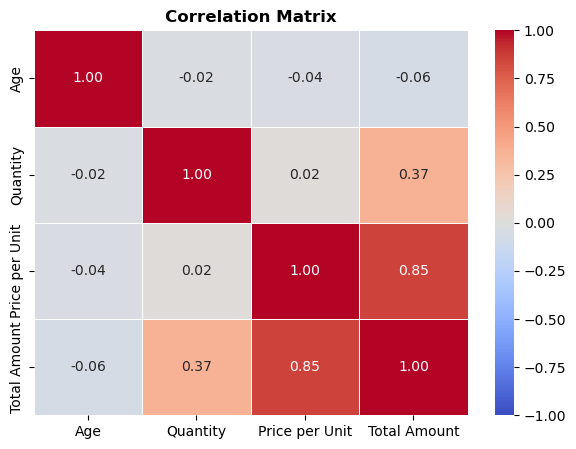

In [26]:
plt.figure(figsize=(7, 5))
corr_matrix = data[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

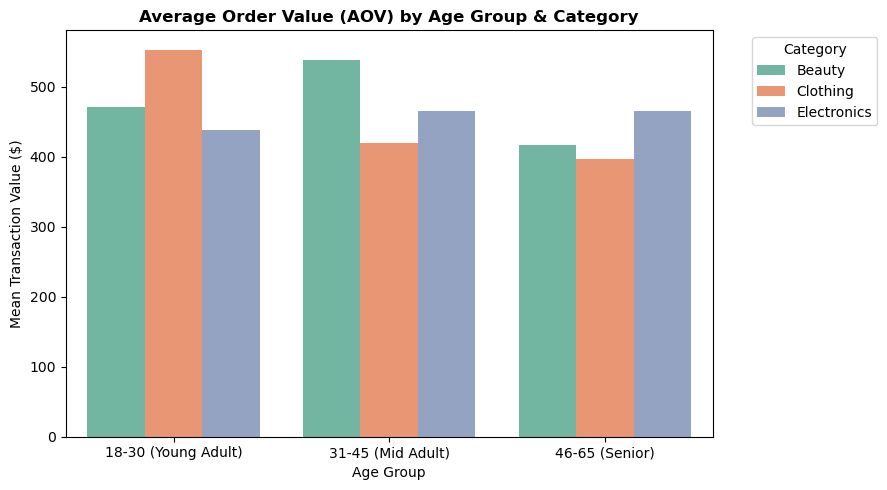

In [28]:
# Binning Age into brackets
data['Age Group'] = pd.cut(data['Age'], bins=[17, 30, 45, 65], labels=['18-30 (Young Adult)', '31-45 (Mid Adult)', '46-65 (Senior)'])

plt.figure(figsize=(9, 5))
sns.barplot(data=data, x='Age Group', y='Total Amount', hue='Product Category', estimator=np.mean, errorbar=None, palette='Set2')
plt.title('Average Order Value (AOV) by Age Group & Category', fontsize=12, fontweight='bold')
plt.ylabel('Mean Transaction Value ($)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()